This project is a study of the roblox engine through a roblox game. It measures load (number of projectiles / bullets) vs server frame time (ms). The load levels are from 2000 to 20000 in increments of 2000 bullets, with a total of 10 different load levels. This was measured across three passes in three roblox servers, totaling to about 215000 frame samples.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

f = pd.read_csv("../data/frame.csv")
m = pd.read_csv("../data/memory.csv")
print(len(f), len(m))
print(f.columns.tolist())

214583 3938
['sweepId', 'serverId', 'runId', 't', 'load', 'phase', 'liveBullets', 'frameMs', 'terminated', 'playerCount']


To start off, testing to see the shape of the load vs frame time (ms) distribution at one load level (16000) in one pass (pass1).

In [46]:
lvl = f[(f.load == 16000) & (f.phase == "steady") & (f.sweepId == "frame1")]
print(len(lvl))

2574


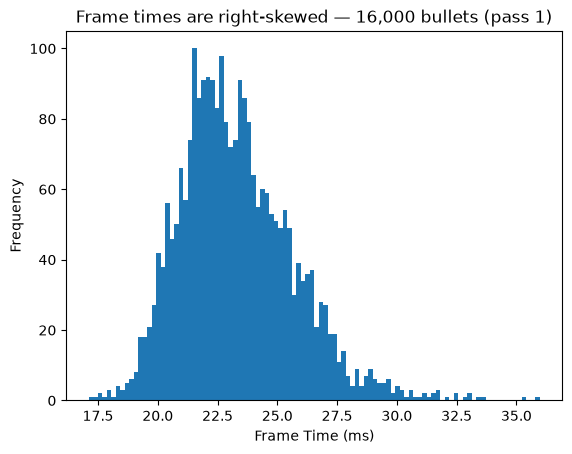

In [47]:
plt.hist(lvl.frameMs, bins = 100)
plt.xlabel("Frame Time (ms)")
plt.ylabel("Frequency")
plt.title("Frame times are right-skewed — 16,000 bullets (pass 1)")
plt.show()

The histogram is right skewed, the bulk of the distribution lies at around 22.5 ms, and the tail goes past 35 ms. This is the reason the project uses percentiles rather than mean / standard deviation.

Next, plot each load level against the three percentiles (p50, p95, p99) in pass1.

In [48]:
steady1 = f[(f.sweepId == "frame1") & (f.phase == "steady")]
pct1 = steady1.groupby("load").frameMs.quantile([0.5, 0.95, 0.99]).unstack()
pct1.columns = ["p50", "p95", "p99"]
pct1

,p50,p95,p99
load,,,
2000,16.678561,17.196775,18.020621
4000,16.680636,17.229161,17.986044
6000,16.668552,16.981010,18.007092
8000,16.668851,16.980876,18.015986
10000,16.665330,17.385636,19.445459
12000,16.902624,20.378114,23.637925
14000,19.387173,23.697844,28.030263
16000,23.011973,27.380764,30.139379
18000,25.780424,30.675263,35.588142


The knee is already visible. At p50, frame times (ms) stays flat at around 16.67 ms from load 2000 to 10000, then it climbs. The p50 to p99 gap widens, ~1.3 ms at 2000, ~11.2 ms at 20000.

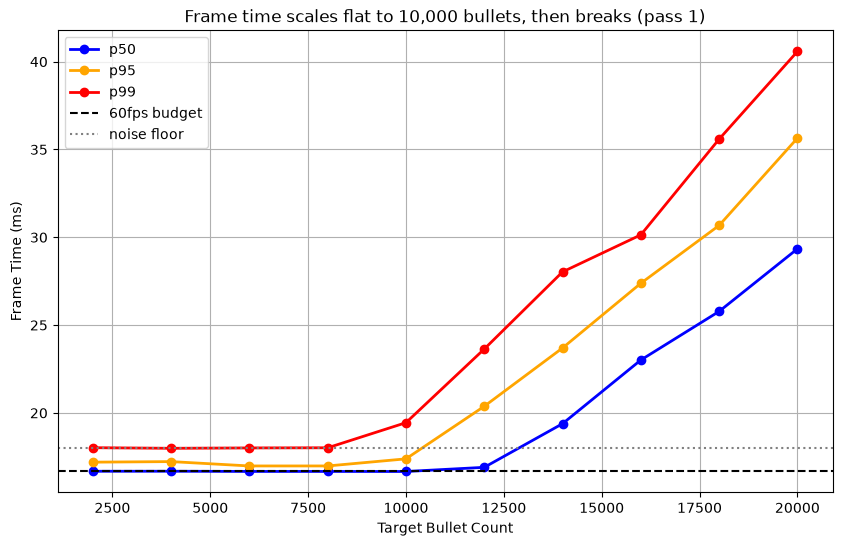

In [49]:
pct1.plot(figsize = (10, 6), marker = "o", linewidth = 2, grid = True, color = ["blue", "orange", "red"], title = "Frame time scales flat to 10,000 bullets, then breaks (pass 1)")
plt.axhline(y = 16.67, color = "black", linestyle = "--", label = "60fps budget")
plt.axhline(y = 18, color = "gray", linestyle = ":", label = "noise floor")
plt.xlabel("Target Bullet Count")
plt.ylabel("Frame Time (ms)")
plt.legend()
plt.show()

The flat regions are visible for all three percentiles (p50, p95, p99), and the sharp bend at each percentile's respective knees show as well. Each percentile's frame times fan out as well.

p99's idle baseline is ~ 18ms, so a 19ms threshold is used to clear the noise floor that was measured.

In [50]:
print("p99 crosses at", pct1[pct1["p99"] > 19].index[0])
print("p95 crosses at", pct1[pct1["p95"] > 18].index[0])
print("p50 crosses at", pct1[pct1["p50"] > 18].index[0])

p99 crosses at 10000
p95 crosses at 12000
p50 crosses at 14000


p99 crosses at 10000, p95 at 12000, and p50 at 14000. The tail degrades before the normal frame.

Testing to see if Bullet terminations coincide with slower frames. Testing at 12000, when p95 is over the noise floor, and at 6000, when the three percentiles, p50, p95, p99, are all under their respective noise floors.

In [51]:
subset12 = steady1[steady1.load == 12000]
slow12 = subset12[subset12.frameMs > 18]
fast12 = subset12[subset12.frameMs <= 18]

print(slow12.terminated.mean())
print(fast12.terminated.mean())

45.09090909090909
38.77078477078477


In [52]:
subset6 = steady1[steady1.load == 6000]
slow6 = subset6[subset6.frameMs > 18]
fast6 = subset6[subset6.frameMs <= 18]

print(slow6.terminated.mean())
print(fast6.terminated.mean())

19.63157894736842
19.532846715328468


At 12000 bullets, slow frames average 16% more terminations than fast ones (45.1 vs 38.8). At 6000, below the knee, the difference is much less noticeable (19.63 vs 19.53), so the association only appears once the server is struggling. The direction is not established, terminations may contribute to frame cost, or a longer frame may just capture more expiries.

Testing to see if the original 2000 bullet load's frame times are more / less / same as the recheck's (also at 2000 bullets) frame times. If the recheck has increased, something likely accumulated during the trial, amplifying the load on the server on the higher bullet loads. If not, then the frame times are not inflated.

In [53]:
frame1_2000 = f[(f.sweepId == "frame1") & (f.load == 2000) & (f.phase == "steady")]
frame1_2000_95th = frame1_2000.frameMs.quantile(0.95)
print(f"2000 Original: {frame1_2000_95th:.3f}")
frame1_recheck = f[(f.sweepId == "frame1_recheck") & (f.phase == "steady")]
frame1_recheck_95th = frame1_recheck.frameMs.quantile(0.95)
print(f"2000 Recheck: {frame1_recheck_95th:.3f}")
print(f"Difference: {frame1_recheck_95th - frame1_2000_95th:.3f}")

2000 Original: 17.197
2000 Recheck: 17.146
Difference: -0.051


Since the difference (recheck - original) is -0.051ms, the recheck is essentially unchanged as the original, and nothing accumulated enough during the trials to register. The recheck is 2000 bullets, below the knee where the server finishes processing before 16.67ms and sleeps. This means that the accumulation did not exceed the headroom the server originally had at 2000 bullets.

Testing to see if the shape of the p95 load vs frame time (ms) is similar between the three servers. It's known that the height of the curves will be different as roblox server hardware varies, but the shape is unknown.

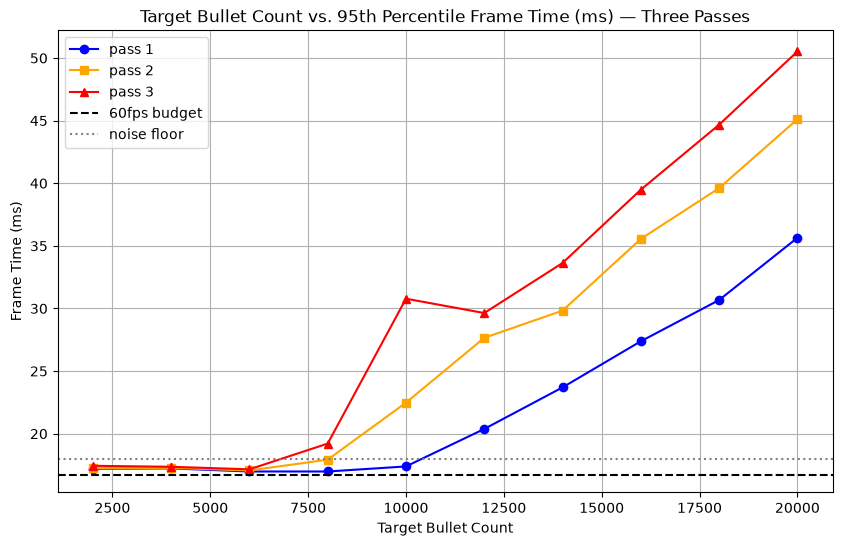

In [54]:
steady2 = f[(f.sweepId == "frame2") & (f.phase == "steady")]
pct2 = steady2.groupby("load").frameMs.quantile([0.5, 0.95, 0.99]).unstack()
pct2.columns = ["p50", "p95", "p99"]

steady3 = f[(f.sweepId == "frame3") & (f.phase == "steady")]
pct3 = steady3.groupby("load").frameMs.quantile([0.5, 0.95, 0.99]).unstack()
pct3.columns = ["p50", "p95", "p99"]

plt.figure(figsize = (10, 6))
plt.plot(pct1.index, pct1["p95"], label = "pass 1", color = "blue", marker = "o")
plt.plot(pct2.index, pct2["p95"], label = "pass 2", color = "orange", marker = "s")
plt.plot(pct3.index, pct3["p95"], label = "pass 3", color = "red", marker = "^")
plt.axhline(y = 16.67, color = "black", linestyle = "--", label = "60fps budget")
plt.axhline(y = 18, color = "gray", linestyle = ":", label = "noise floor")
plt.xlabel("Target Bullet Count")
plt.ylabel("Frame Time (ms)")
plt.legend()
plt.grid(True)
plt.title("Target Bullet Count vs. 95th Percentile Frame Time (ms) — Three Passes")
plt.show()

The same shape replicated on all three passes' p95 load vs frame time (ms). On low loads, the frame time is consistent at 16.67ms, but as the load approaches and passes the knee, the frame times increase, each pass climbing at a similar rate, just starting at different loads and heights. The shape is consistent between the three passes. On pass 3, there is a kink at 10000 to 12000 where frame time drops as load rises, which shouldn't happen. That point likely caught a transient, GC or datacenter contention. Recon flagged one server as unstable run to run, which can explain this.

Analyzing memory now. Three questions, does memory scale with load, does it drift at a constant load, and does memory go back to normal after a high load.

Computing mean memory per level minus the idle baseline. This shows memory due to bullets rather than total server memory.

In [55]:
msteady1 = m[(m.sweepId == "frame1") & (m.phase == "steady")]
mbase1 = m[(m.sweepId == "frame1_base") & (m.phase == "idle")]
memByLoad = msteady1.groupby("load").memoryMb.mean() - mbase1.memoryMb.mean()
memByLoad

load
2000      6.088867
4000     12.354036
6000     15.595117
8000     13.763672
10000    21.367643
12000    22.827344
14000    25.002148
16000    27.465820
18000    30.262956
20000    26.842839
Name: memoryMb, dtype: float64

In [56]:
print(memByLoad / memByLoad.index)

load
2000     0.003044
4000     0.003089
6000     0.002599
8000     0.001720
10000    0.002137
12000    0.001902
14000    0.001786
16000    0.001717
18000    0.001681
20000    0.001342
dtype: float64


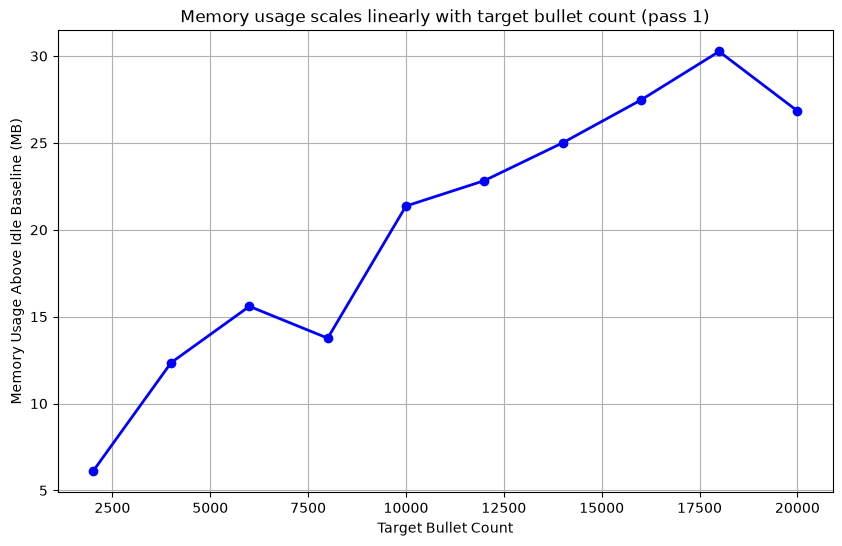

In [57]:
memByLoad.plot(figsize = (10, 6), marker = "o", linewidth = 2, grid = True, color = "blue", title = "Memory usage scales linearly with target bullet count (pass 1)")
plt.xlabel("Target Bullet Count")
plt.ylabel("Memory Usage Above Idle Baseline (MB)")
plt.show()

The memory attributable to bullets rises roughly linearly. It's about 1.7KB per bullet at a high load. Lower level per bullet memory numbers are inflated due to most likely fixed overhead cost and noise. The dips at 8000 and 20000 are GC / sampling noise since memory can't fall when bullets are added.

Testing whether or not the memory drifts upward at a constant 5000 bullet load for 8 minutes.

In [66]:
hold1 = m[(m.sweepId == "leak1") & (m.load > 0) & (m.phase == "steady")]
hold1Slope, hold1Intercept = np.polyfit(hold1.t, hold1.memoryMb, 1)
hold1Drift = hold1Slope * 480
print("Slope: " + str(hold1Slope) + ", Drift: " + str(hold1Drift))

Slope: -0.005778651232109296, Drift: -2.773752591412462


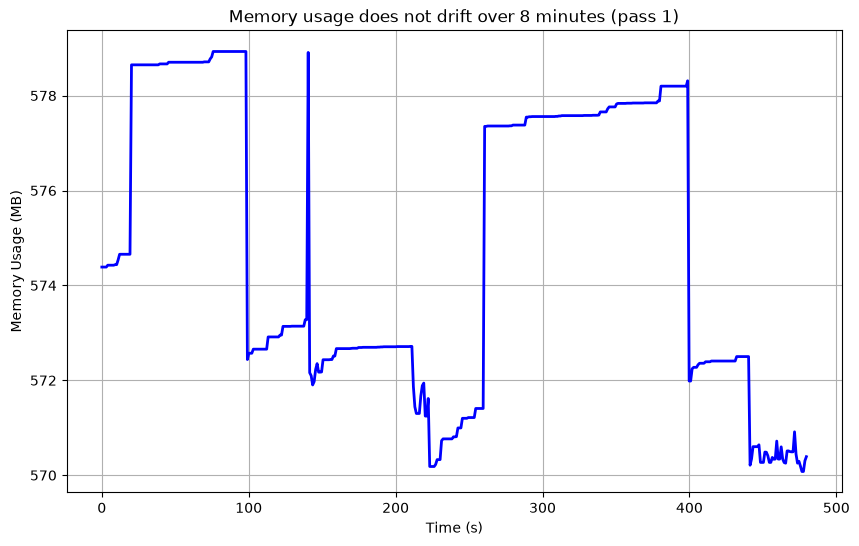

In [65]:
hold1.plot(x = "t", y = "memoryMb", figsize = (10, 6), legend = False, linewidth = 2, grid = True, color = "blue", title = "Memory usage does not drift over 8 minutes (pass 1)")
plt.xlabel("Time (s)")
plt.ylabel("Memory Usage (MB)")
plt.show()

Memory does not drift upwards at a constant load of 5000 bullets for 8 minutes. The slope is about -0.0058 MB/s, with a total of -2.77 MB. The sawtooth shape shows the normal behavior of the GC, allocate and collect. The important part is that the troughs aren't rising. No leak detectable during the hold. The sawtooth amplitude (~9 MB) is comparable to the entire memory vs load effect which explains the per level noise.

In [71]:
print("Instance count is constant: " + str(min(hold1.instanceCount) == max(hold1.instanceCount)) + ", Instance count: " + str(hold1.instanceCount.iloc[0]))

Instance count is constant: True, Instance count: 100876


Bit identical across all 476 samples, no instance leak, bullets are pure luau tables.

Testing to see if the memory returns to the baseline after a high bullet load.

In [ ]:
hold1_recheck = m[(m.sweepId == "leak1") & (m.load == 0) & (m.phase == "idle")]
sameServer1 = hold1_recheck.serverId.iloc[0] == mbase1.serverId.iloc[0]
tailDelta1 = hold1_recheck.memoryMb.mean() - mbase1.memoryMb.mean()

print("pass1")
print(f"Tail vs idle baseline: {tailDelta1:+.2f} MB")
print(f"Same server: {sameServer1}")

Tail vs idle baseline: +25.59 MB
Same server: True


In [75]:
hold2_recheck = m[(m.sweepId == "leak2") & (m.load == 0) & (m.phase == "idle")]
mbase2 = m[(m.sweepId == "frame2_base") & (m.phase == "idle")]
sameserver2 = hold2_recheck.serverId.iloc[0] == mbase2.serverId.iloc[0]
tailDelta2 = hold2_recheck.memoryMb.mean() - mbase2.memoryMb.mean()

print("pass2")
print(f"Tail vs idle baseline: {tailDelta2:+.2f} MB")
print(f"Same server: {sameserver2}")

hold3_recheck = m[(m.sweepId == "leak3") & (m.load == 0) & (m.phase == "idle")]
mbase3 = m[(m.sweepId == "frame3_base") & (m.phase == "idle")]
sameserver3 = hold3_recheck.serverId.iloc[0] == mbase3.serverId.iloc[0]
tailDelta3 = hold3_recheck.memoryMb.mean() - mbase3.memoryMb.mean()

print("\npass3")
print(f"Tail vs idle baseline: {tailDelta3:+.2f} MB")
print(f"Same server: {sameserver3}")

pass2
Tail vs idle baseline: +32.30 MB
Same server: True

pass3
Tail vs idle baseline: +34.87 MB
Same server: True


Memory sits at +25.6/ +32.3/ + 34.9 MB above the baseline after clearing on all three trials (same server confirmed). That is consistent with the allocator page retention, the hold slope was flat, instanceCount was flat, and the amount matches the peak bullet load memory. However, a 2 minute tail can't separate that from a slow leak, a longer tail is necessary to see if the memory drops or not.

The findings. Memory scales with bullet count, roughly linearly. There is no memory drift at a consistent load, as shown in the three trials. There is no instance retention, instanceCount is bit identical throughout all of the trials. Memory does not return to the baseline within the 2 minute tail (+ 25 to +35 MB across trails). Consistent with allocator page retention given the flat hold slope flat instanceCount , but a 2 minute window can't rule out a slow leak. A longer tail is necessary in the future. The original concern of live bullets' unbounded growth risk which the project was meant to measure did not appear in the data.